In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    roc_auc_score, 
    roc_curve, 
    auc
)
from sklearn.preprocessing import label_binarize

# 1. Load Data and Models
data = np.load('../data/fashion_data_complete.npz')
X_test = data['X_test']
y_test = data['y_test']
class_names = data['class_names']

# Dictionary of your 4 models (Update filenames if needed)
model_files = {
    "k-NN": "../models/knn_fashion_model.joblib",
    "SVM": "../models/svm_fashion_model.joblib",
    "Random Forest": "../models/random_forest_fashion_model.joblib",
    "MLP": "../models/mlp_fashion_model.joblib" # Assuming Hieu's model name
}

models = {}
for name, file in model_files.items():
    try:
        models[name] = joblib.load(file)
        print(f"Loaded {name}")
    except:
        print(f"Warning: Could not find {file}")



Loaded k-NN
Loaded SVM
Loaded Random Forest
Loaded MLP



==================== k-NN ====================
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.86      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.76      0.77      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.78      0.80      0.79      1000
      Sandal       0.98      0.83      0.90      1000
       Shirt       0.64      0.64      0.64      1000
     Sneaker       0.88      0.94      0.91      1000
         Bag       0.98      0.94      0.96      1000
  Ankle boot       0.89      0.96      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


==================== SVM ====================
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       0.99      0.98    

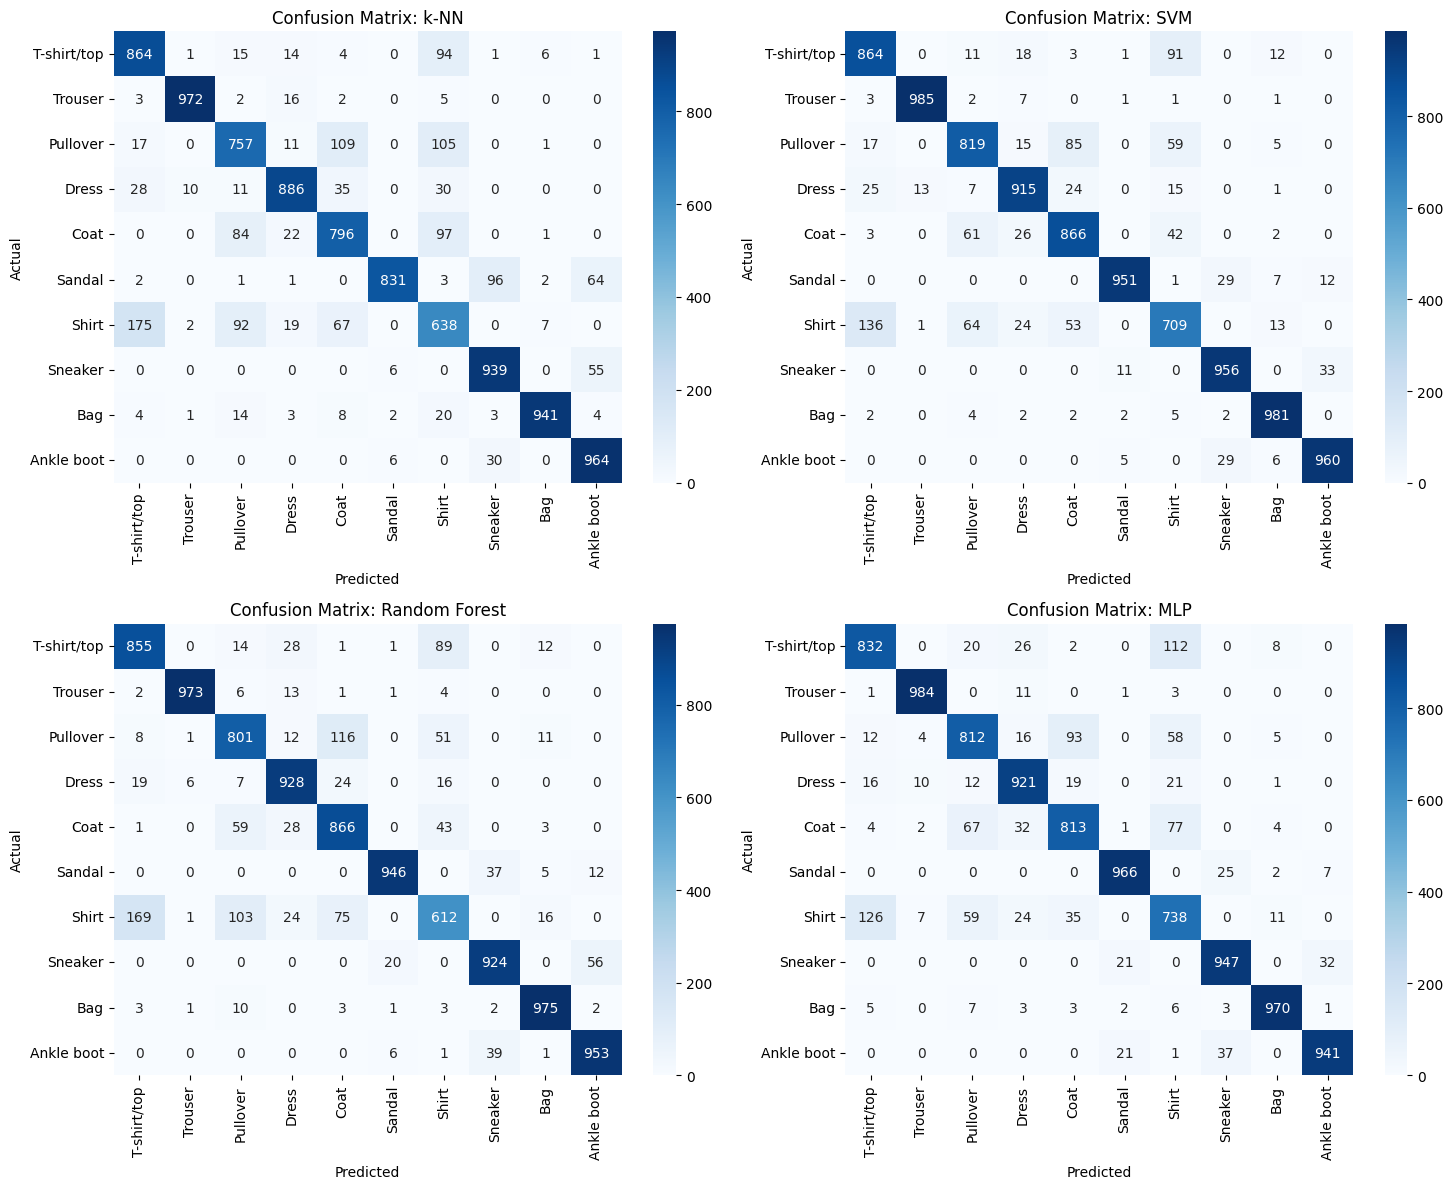

In [4]:
# 2. Binarize labels for Multi-class ROC-AUC
y_test_binarized = label_binarize(y_test, classes=range(10))

# 3. Evaluation Loop
results_summary = []

plt.figure(figsize=(15, 12)) # For Confusion Matrices

for i, (name, model) in enumerate(models.items()):
    # Get Predictions
    y_pred = model.predict(X_test)
    
    # Get Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        # For SVM if probability=False, use decision_function
        y_score = model.decision_function(X_test)
        # Normalize scores to look like probabilities for the metric
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    # --- Metrics ---
    acc = accuracy_score(y_test, y_pred)
    # Multi-class ROC-AUC (Macro average)
    roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
    
    results_summary.append({
        "Model": name,
        "Accuracy": acc,
        "ROC-AUC (Macro)": roc_auc
    })

    # --- Print Classification Report ---
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # --- Plot Confusion Matrix ---
    plt.subplot(2, 2, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()


In [5]:

# 4. Show Summary Table
df_compare = pd.DataFrame(results_summary).sort_values(by='Accuracy', ascending=False)
print("\n--- Model Comparison Summary ---")
print(df_compare)




--- Model Comparison Summary ---
           Model  Accuracy  ROC-AUC (Macro)
1            SVM    0.9006         0.993764
3            MLP    0.8924         0.991769
2  Random Forest    0.8833         0.991193
0           k-NN    0.8588         0.970239


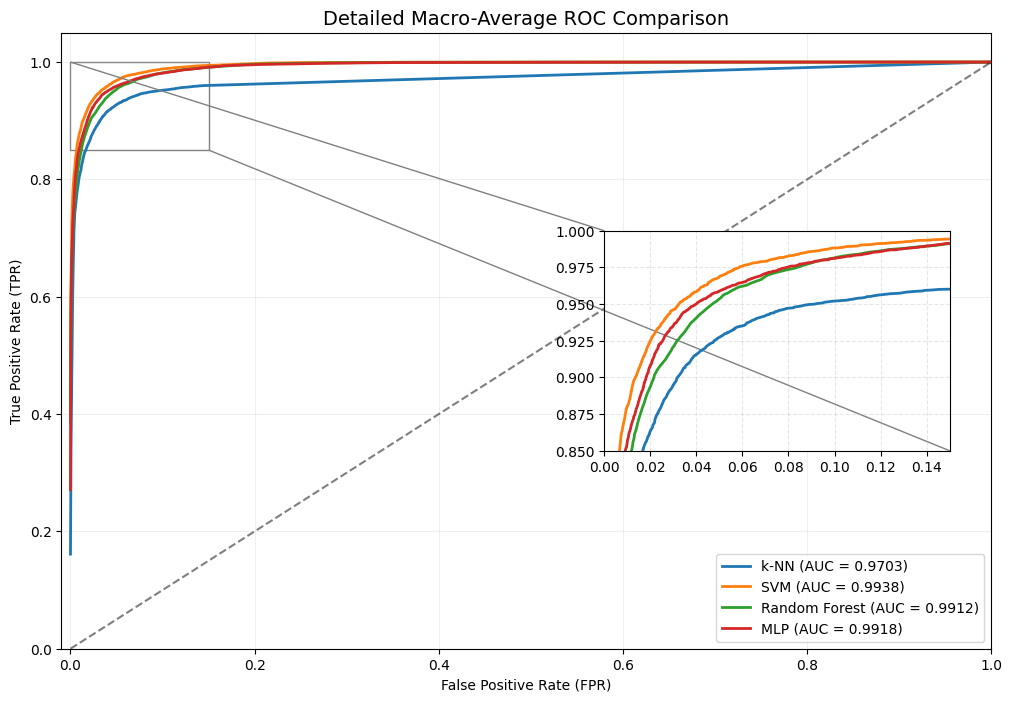

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# Create the main plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define the zoom area (Top-left corner where curves diverge)
x1, x2, y1, y2 = 0.0, 0.15, 0.85, 1.0  
axins = zoomed_inset_axes(ax, zoom=2.5, loc='center right', borderpad=3) # zoom factor and location

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    
    # Standard OvR Macro-average calculation
    fpr = dict()
    tpr = dict()
    for j in range(10):
        fpr[j], tpr[j], _ = roc_curve(y_test_binarized[:, j], y_score[:, j])

    all_fpr = np.unique(np.concatenate([fpr[j] for j in range(10)]))
    mean_tpr = np.zeros_like(all_fpr)
    for j in range(10):
        mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
    mean_tpr /= 10
    
    current_auc = auc(all_fpr, mean_tpr)
    label_text = f'{name} (AUC = {current_auc:.4f})'
    
    # Plot on main axis
    ax.plot(all_fpr, mean_tpr, label=label_text, lw=2)
    # Plot on zoomed inset
    axins.plot(all_fpr, mean_tpr, lw=2)

# Format Main Axis
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('Detailed Macro-Average ROC Comparison', fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.2)

# Format Inset Axis
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(alpha=0.3, linestyle='--')
plt.xticks(visible=True)
plt.yticks(visible=True)

# Draw the lines connecting main plot to the zoom box
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", lw=1)

plt.show()